In [4]:
import os
import warnings
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
)
# global Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [6]:
# 1 download ans load dataset
print("step 1: downloading span database from source")
print("=" * 45)
url_direct = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

try:
    urllib.request.urlretrieve(url_direct, "sms_data.tsv")
    print("Dataset downloaded successfully from GitHub mirror!")
    df = pd.read_csv("sms_data.tsv", sep='\t', header=None, names=['label', 'message'])
except Exception as e:
    print("Primary source failed. Loading fallback dataset from sklearn...")

    from sklearn.datasets import fetch_20newsgroups
    ham = fetch_20newsgroups(subset='train', categories=['rec.sport.baseball'], shuffle=True, random_state=42)
    spam = fetch_20newsgroups(subset='train', categories=['sci.crypt'], shuffle=True, random_state=42)
    
    # use min length to avoid mismatch
    ham_size = min(1000, len(ham.data))
    spam_size = min(1000, len(spam.data))

    messages = list(ham.data[:ham_size]) + list(spam.data[:spam_size])
    labels = ['ham'] * ham_size + ['spam'] * spam_size
    df = pd.DataFrame({'label': labels, 'message': messages})

# dataset exploration
print(f"dataset shape: {df.shape}")
print("first 5 messages:")
print(df.head())

print("class Distribution:")
print(df['label'].value_counts())
spam_pct = df['label'].value_counts(normalize=True)['spam'] * 100
print(f"Spam percentage: {spam_pct:.2f}%")



step 1: downloading span database from source
Dataset downloaded successfully from GitHub mirror!
dataset shape: (5572, 2)
first 5 messages:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64
Spam percentage: 13.41%


STEP 2: VISUALIZING SPAM VS HAM PATTERNS


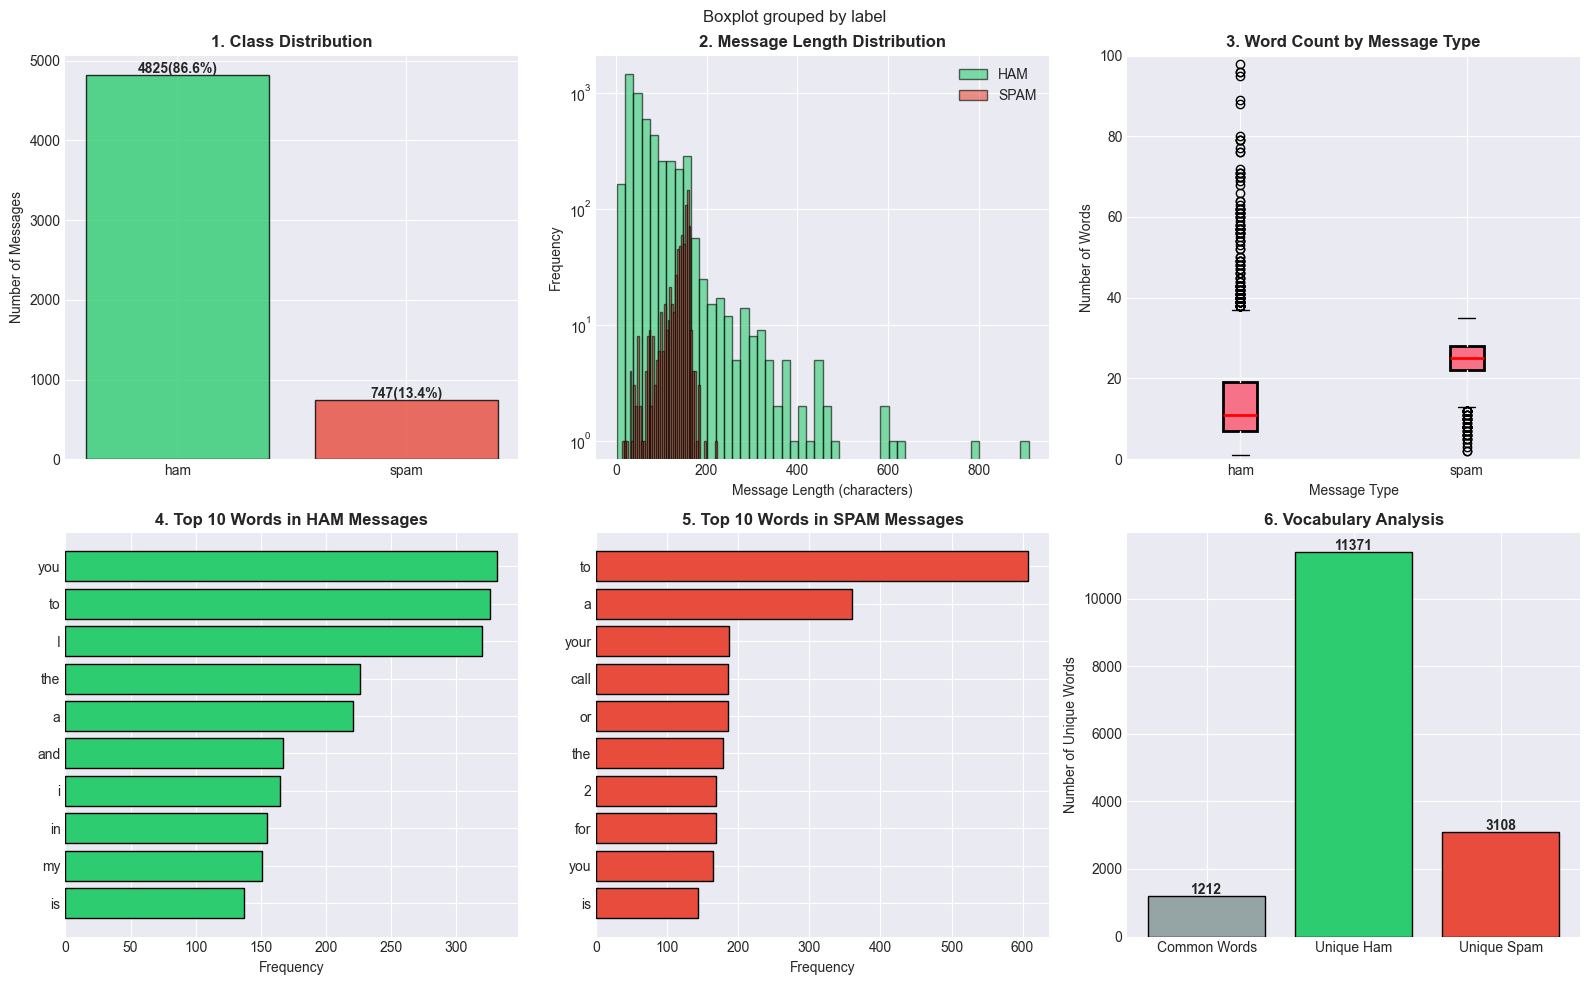

In [10]:
# 2 exploraroty data analysis and visualization
print("STEP 2: VISUALIZING SPAM VS HAM PATTERNS")
print("=" * 45)

from collections import Counter
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('SMS/Email Spam Classification - Data Analysis', fontsize=16, fontweight='bold')

# 1. Class distribution
ax1 = axes[0, 0]
class_counts = df['label'].value_counts()
colors_class = ['#2ecc71', '#e74c3c']
bars = ax1.bar(class_counts.index, class_counts.values, color=colors_class, edgecolor='black', alpha=0.8)
ax1.set_title('1. Class Distribution', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Messages')
for bar, count in zip(bars, class_counts.values):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20, 
             f'{count}({count / len(df) * 100:.1f}%)', ha='center', fontweight='bold')


# 2. Message length distribution (Histogram)
ax2 = axes[0, 1]
df['message_length'] = df['message'].str.len()
for label, color in zip(['ham', 'spam'], ['#2ecc71', '#e74c3c']):
    subset = df[df['label'] == label]['message_length']
    ax2.hist(subset, bins=50, alpha=0.6, label=label.upper(), color=color, edgecolor='black')
ax2.set_title('2. Message Length Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Message Length (characters)')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.set_yscale('log')


# 3. Word count distribution(Boxplot)
ax3 = axes[0, 2]
df['word_count'] = df['message'].str.split().str.len()
df.boxplot(column='word_count', by='label', ax=ax3, patch_artist=True,
           boxprops=dict(linewidth=2), medianprops=dict(linewidth=2, color='red'))
ax3.set_title('3. Word Count by Message Type', fontsize=12, fontweight='bold')
ax3.set_xlabel('Message Type')
ax3.set_ylabel('Number of Words')
ax3.set_ylim(0, 100)


# 4. Top words in HAM messages
ax4 = axes[1, 0]
ham_words = ' '.join(df[df['label'] == 'ham']['message'].head(1000)).split()
ham_top10 = Counter(ham_words).most_common(10)
words_ham, counts_ham = zip(*ham_top10)
ax4.barh(words_ham, counts_ham, color='#2ecc71', edgecolor='black')
ax4.set_title('4. Top 10 Words in HAM Messages', fontsize=12, fontweight='bold')
ax4.set_xlabel('Frequency')
ax4.invert_yaxis()


# 5. Top words in SPAM messages
ax5 = axes[1, 1]
spam_words = ' '.join(df[df['label'] == 'spam']['message'].head(1000)).split()
spam_top10 = Counter(spam_words).most_common(10)
words_spam, counts_spam = zip(*spam_top10)
ax5.barh(words_spam, counts_spam, color='#e74c3c', edgecolor='black')
ax5.set_title('5. Top 10 Words in SPAM Messages', fontsize=12, fontweight='bold')
ax5.set_xlabel('Frequency')
ax5.invert_yaxis()


# 6. Common vs Unique words
ax6 = axes[1, 2]
ham_set = set(' '.join(df[df['label'] == 'ham']['message']).split())
spam_set = set(' '.join(df[df['label'] == 'spam']['message']).split())
common_words = len(ham_set.intersection(spam_set))
unique_ham = len(ham_set - spam_set)
unique_spam = len(spam_set - ham_set)
x_labels = ['Common Words', 'Unique Ham', 'Unique Spam']
y_vals = [common_words, unique_ham, unique_spam]
ax6.bar(x_labels, y_vals, color=['#95a5a6', '#2ecc71', '#e74c3c'], edgecolor='black')
ax6.set_title('6. Vocabulary Analysis', fontsize=12, fontweight='bold')
ax6.set_ylabel('Number of Unique Words')
for i, (bar_name, val) in enumerate(zip(x_labels, y_vals)):
    ax6.text(i, val + 50, str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


In [11]:
# 3 text preprocessing and feature enginnering 
#Transform raw text into numerical sparse matrices using TF-IDF vectorization with unigrams and bigrams
print("STEP 3: TEXT PREPROCESSING & FEATURE ENGINEERING")
print("=" * 45)
# Binary encoding: 1 = Spam, 0 = Ham
y = (df['label'] == 'spam').astype(int)
X_text = df['message']
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(
    max_features=3000,
    stop_words='english',
    ngram_range=(1, 2),
    lowercase=True,
    max_df=0.8,
    min_df=2
)
X = vectorizer.fit_transform(X_text)
print(f"Feature matrix shape: {X.shape}")
print(f"Sample features: {vectorizer.get_feature_names_out()[:15]}")
# Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Baseline accuracy: {max(y.value_counts(normalize=True)) * 100:.2f}%")

STEP 3: TEXT PREPROCESSING & FEATURE ENGINEERING
Feature matrix shape: (5572, 3000)
Sample features: ['00' '00 sub' '000' '000 bonus' '000 cash' '02' '03' '03 2nd' '04' '05'
 '06' '06 03' '0800' '0800 542' '08000839402']
Training set: 4457 samples
Test set: 1115 samples
Baseline accuracy: 86.59%


In [12]:
#4 Train Naive Bayes Model
#Train a Multinomial Naive Bayes classifier applying Laplace smoothing with α = 0.5

print("STEP 4: TRAINING NAIVE BAYES CLASSIFIER")
print("=" * 45)
model = MultinomialNB(alpha=0.5)
model.fit(X_train, y_train)
print("Model trained successfully!")
print(f"Smoothing Parameter (alpha): {model.alpha}")

STEP 4: TRAINING NAIVE BAYES CLASSIFIER
Model trained successfully!
Smoothing Parameter (alpha): 0.5


In [ ]:
#Learning Curves Analysis
#Assess model generalization and verify that no overfitting or underfitting occurs across training sizes
